# 3. Block Position Cycle 회귀모델 구축 및 평가

데이터 생성 순서를 기준으로 모델링을 두 부분으로 나눈다.

1. **최종 예측모델**: 스케줄링 이전에 알 수 있는 Set A(Block 고유 특성)에서 모델을 비교·튜닝한다.
2. **탐색적 진단**: DDQN 선택 결과가 포함된 Set B/C를 같은 모델로 비교하되 최종 예측모델로 채택하지 않는다.

> 선택 Position은 Scheduling Result이므로 최종 Cycle 예측의 사전 독립변수에서 제외한다. 모든 비교에는 동일한 train/test 분할을 사용하고 MAE, RMSE, R²를 평가한다.


## 3.1 분석 데이터와 변수 세트 불러오기

2번 노트북에서 저장한 `analysis_DDQN.csv`와 `feature_sets_DDQN.json`을 불러온다. 이 노트북은 앞 노트북의 메모리 상태에 의존하지 않고 단독으로 실행된다.

In [1]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================

# 파일 및 설정값 처리
import json
from pathlib import Path

# 모델 저장 및 데이터 처리
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Scikit-learn 공통 기능
from sklearn.base import clone
from sklearn.compose import ColumnTransformer

# 회귀모델
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge

# from sklearn.linear_model import Lasso, ElasticNet
# 규제모델 비교 자체가 목적이 아니므로,
# 다중공선성 완화를 대표하는 Ridge만 사용

from sklearn.tree import DecisionTreeRegressor

# from sklearn.ensemble import GradientBoostingRegressor
# 앙상블 모델 종류를 과도하게 늘리지 않고,
# Feature Set 및 스케줄링 방식 비교에 집중하기 위해 Random Forest만 사용

# 모델 평가 및 학습
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# ============================================================
# 2. 분석 데이터 및 Feature Set 설정 파일 경로 지정
# ============================================================

# 전처리와 모델링 결과 저장 경로
PROCESSED_DIR = Path('data') / 'processed'
OUTPUT_DIR = Path('outputs') / '3_modeling'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 전처리가 완료된 DDQN 분석 데이터
DATA_PATH = PROCESSED_DIR / 'analysis_DDQN.csv'

# Set A / B / C 및 Target 정보가 저장된 JSON 파일
FEATURE_PATH = PROCESSED_DIR / 'feature_sets_DDQN.json'


# ============================================================
# 3. 분석 데이터 불러오기
# ============================================================

analysis = pd.read_csv(DATA_PATH)


# ============================================================
# 4. Feature Set 설정 불러오기
# ============================================================

# JSON 파일에서 Target과 Set A / B / C 변수 목록 불러오기
with open(FEATURE_PATH, encoding='utf-8') as file:
    feature_config = json.load(file)

# 종속변수 설정
target_col = feature_config['target']

# Feature Set 구성
# Set A → Block 자체 특성
# Set B → Block + DDQN이 선택한 Position 특성
# Set C → Block + Position + Initial 상태 정보
feature_sets = {
    'Set A - Block': feature_config['set_a'],
    'Set B - Block + Position': feature_config['set_b'],
    'Set C - Block + Position + Initial': feature_config['set_c']
}


# ============================================================
# 5. 분석에 필요한 컬럼 존재 여부 확인
# ============================================================

# Target과 모든 Feature Set에서 사용하는 컬럼을 하나의 집합으로 정리
required_cols = set(
    [target_col]
    + sum(feature_sets.values(), [])
)

# 필요한 컬럼 중 실제 analysis 데이터에 존재하지 않는 컬럼 확인
missing_cols = sorted(
    required_cols - set(analysis.columns)
)


# ============================================================
# 6. 데이터 및 Feature Set 기본 정보 확인
# ============================================================

print('데이터 크기:', analysis.shape)
print('전체 결측값:', analysis.isna().sum().sum())
print('누락된 필요 컬럼:', missing_cols)

print()
print('변수 세트 크기:')

for name, columns in feature_sets.items():
    print(f'- {name}: {len(columns)}개')


# ============================================================
# 7. 필수 컬럼 누락 여부 최종 검증
# ============================================================

# 필요한 컬럼이 하나라도 누락된 경우 이후 모델링을 중단
assert not missing_cols, (
    f'분석 데이터에 필요한 컬럼이 없습니다: {missing_cols}'
)

데이터 크기: (872, 20)
전체 결측값: 0
누락된 필요 컬럼: []

변수 세트 크기:
- Set A - Block: 8개
- Set B - Block + Position: 17개
- Set C - Block + Position + Initial: 18개


## 3.2 공통 학습·평가 조건

- train/test 비율: 80% / 20%
- `random_state=42`
- 범주형 변수: One-Hot Encoding
- 수치형 변수: Standard Scaling
- 평가 지표: MAE, RMSE, R²

행 인덱스를 한 번만 분할하여 모든 변수 세트와 모델에 동일한 학습·평가 표본을 사용한다.


In [2]:
# ============================================================
# 1. Train / Test 데이터 인덱스 분리
# ============================================================

# 전체 데이터의 index를 기준으로 학습용 80%, 테스트용 20%로 분리
# → Set A / B / C 모두 동일한 행을 사용하여 공정하게 비교
train_index, test_index = train_test_split(analysis.index, test_size=0.2, random_state=42)

# 종속변수도 동일한 index 기준으로 학습용 / 테스트용 분리
y_train = analysis.loc[train_index, target_col]
y_test = analysis.loc[test_index, target_col]


# ============================================================
# 2. 비교할 회귀모델 정의
# ============================================================

# 동일한 Feature Set에 여러 회귀모델을 적용하여 성능 비교
model_candidates = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)

    # , 'Lasso': Lasso(alpha=1.0)
    # , 'Elastic Net': ElasticNet(alpha=1.0, l1_ratio=0.5)
    # , 'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# 선정 이유
    # Linear Regression → 기본 선형 기준 모델로 변수와 Cycle의 관계 확인
    # Ridge → 다중공선성이 있는 경우 L2 규제를 통한 안정성 확인
    # Decision Tree → 선형모델이 설명하지 못하는 비선형 관계 확인
    # Random Forest → 여러 Tree를 결합해 안정적인 비선형 예측 성능 확인

# 제외 사유
    # Lasso / Elastic Net → 규제모델 비교 자체가 목적이 아니므로 대표 모델인 Ridge만 사용
    # Gradient Boosting → 모델 종류를 과도하게 늘리지 않고 Feature Set 및 스케줄링 방식 비교에 집중하기 위해 제외


# ============================================================
# 3. 전처리 + 모델 학습 Pipeline 생성 함수
# ============================================================

def build_pipeline(feature_cols, estimator):

    # 선택한 독립변수를 수치형 / 범주형 변수로 구분
    numeric_cols = analysis[feature_cols].select_dtypes(include='number').columns.tolist()
    categorical_cols = [col for col in feature_cols if col not in numeric_cols]

    # 수치형은 표준화, 범주형은 One-Hot Encoding 적용
    preprocessor = ColumnTransformer([
        ('numeric', StandardScaler(), numeric_cols),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

    # 전처리와 회귀모델을 하나의 Pipeline으로 연결
    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', clone(estimator))
    ])


# ============================================================
# 4. 회귀모델 성능 평가 함수
# ============================================================

def regression_metrics(y_true, y_pred):

    # MAE, RMSE, R²를 이용하여 예측 성능 평가
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }


# ============================================================
# 5. Feature Set별 모델 비교 함수
# ============================================================

def compare_models(feature_cols, candidates):

    # 동일한 train/test index를 기준으로 Feature Set만 변경
    X_train = analysis.loc[train_index, feature_cols]
    X_test = analysis.loc[test_index, feature_cols]

    records = []
    fitted_models = {}

    # 후보 모델을 동일한 데이터에 순차적으로 학습
    for model_name, estimator in candidates.items():

        pipeline = build_pipeline(feature_cols, estimator)
        pipeline.fit(X_train, y_train)
        prediction = pipeline.predict(X_test)

        # 모델별 성능지표 저장
        records.append({
            'Model': model_name,
            **regression_metrics(y_test, prediction)
        })

        # 이후 잔차분석 등에 활용할 수 있도록 학습된 모델 저장
        fitted_models[model_name] = pipeline

    # RMSE가 낮은 모델부터 정렬
    results = pd.DataFrame(records).sort_values('RMSE').reset_index(drop=True)

    return results, fitted_models


# ============================================================
# 6. Train / Test 분리 결과 확인
# ============================================================

print('학습 데이터:', len(train_index))
print('테스트 데이터:', len(test_index))

학습 데이터: 697
테스트 데이터: 175


## 3.3 기준모델(Baseline) 비교

### 3.3.1 Set A — Block 특성만 사용

Linear Regression, Ridge, Decision Tree, Random Forest를 동일한 Set A와 동일한 데이터 분할로 비교한다.


In [3]:
# ============================================================
# Set A - Block 특성만 사용한 Baseline 모델 비교
# ============================================================

# Block 자체 특성만 포함한 Set A를 Baseline Feature로 설정
# → Position 정보를 추가하기 전 사전 Block Position Cycle의 기본 설명력 확인
baseline_features = feature_sets['Set A - Block']

# 동일한 Train/Test 데이터와 4개 회귀모델을 이용해 Baseline 성능 비교
baseline_results, baseline_models = compare_models(baseline_features, model_candidates)

# 모델별 MAE, RMSE, R² 결과 확인
baseline_results.round(3)

,Model,MAE,RMSE,R2
0,Random Forest,2.953,4.489,0.774
1,Decision Tree,3.423,6.339,0.549
2,Ridge,6.128,7.916,0.297
3,Linear Regression,6.235,8.047,0.274


### 3.3.2 Set A 최종 후보모델 선정

Set A에서 테스트 RMSE가 가장 낮은 모델을 최종 후보이자 Set A/B/C 탐색 비교의 대표모델로 선정한다. 이후 변수 추가 실험에서는 모델과 학습 조건을 고정한다.


In [4]:
# ============================================================
# Baseline 결과를 기준으로 대표 모델 선정
# ============================================================

# Set A에서 RMSE가 가장 낮은 모델을 대표 모델로 선택
representative_name = baseline_results.loc[0, 'Model']

# 이후 Set B / C 및 스케줄링 방식 비교에 사용할 모델 객체 불러오기
representative_estimator = model_candidates[representative_name]

# 선정된 대표 모델 확인
print('대표모델:', representative_name)

대표모델: Random Forest


## 3.4 탐색적 변수 추가 효과 비교

Set A에서 선정한 대표모델과 학습 조건을 고정하고 입력변수만 바꾼다.

- Set A: Block 고유 특성
- Set B: Block + DDQN 선택 Position
- Set C: Block + DDQN 선택 Position + Initial 기록 여부

이 비교는 사후 결과층 변수를 추가했을 때 통계적 예측력이 어떻게 변하는지를 확인하는 **모델 설계 진단**이다. Set B/C의 성능이나 변수 중요도를 Position의 인과효과 또는 Scheduling Method의 성과로 해석하지 않는다.


In [5]:
# ============================================================
# 대표 모델을 이용한 Set A / B / C 성능 비교
# ============================================================

# Feature Set별 성능 결과와 학습된 모델을 저장
set_records = []
set_models = {}

# 대표 모델은 동일하게 유지하고 Feature Set만 변경하여 학습 및 평가
for set_name, feature_cols in feature_sets.items():

    pipeline = build_pipeline(feature_cols, representative_estimator)
    pipeline.fit(analysis.loc[train_index, feature_cols], y_train)
    prediction = pipeline.predict(analysis.loc[test_index, feature_cols])

    # Set별 변수 개수와 MAE, RMSE, R² 저장
    set_records.append({
        'Variable Set': set_name,
        'Variables': len(feature_cols),
        **regression_metrics(y_test, prediction)
    })

    # 이후 잔차분석 등에 활용할 수 있도록 학습된 모델 저장
    set_models[set_name] = pipeline


# Set별 결과를 RMSE가 낮은 순으로 정렬
set_results = pd.DataFrame(set_records).sort_values('RMSE').reset_index(drop=True)

# Set A / B / C 성능 비교
set_results.round(3)

,Variable Set,Variables,MAE,RMSE,R2
0,Set A - Block,8,2.953,4.489,0.774
1,Set C - Block + Position + Initial,18,3.495,4.990,0.721
2,Set B - Block + Position,17,3.494,5.029,0.716


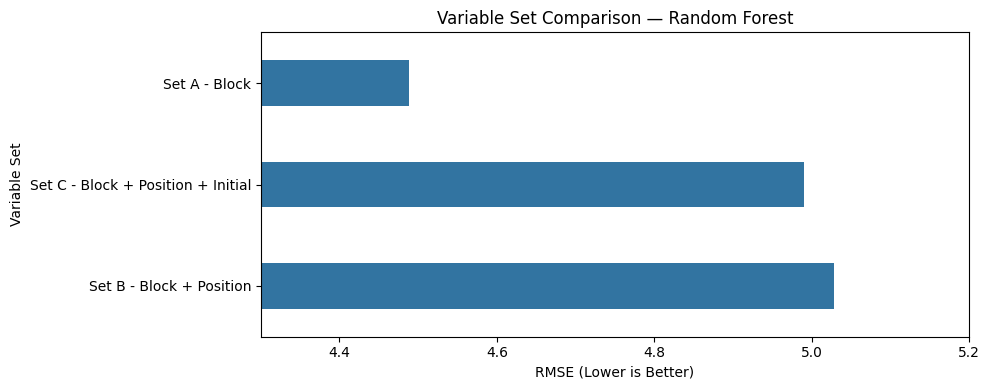

In [6]:
# ============================================================
# Set A / B / C RMSE 차이 시각화
# ============================================================

# RMSE가 낮은 순으로 정렬
plot_data = set_results.sort_values('RMSE')

# 그래프 가로 길이를 늘려 차이가 과도하게 강조되지 않도록 표현
plt.figure(figsize=(10, 4))

# RMSE 범위를 확대하고 얇은 막대로 Set별 성능 차이 표현
sns.barplot(data=plot_data, x='RMSE', y='Variable Set', width=0.45)

# 작은 RMSE 차이가 잘 보이도록 x축 범위 제한
plt.xlim(4.3, 5.2)

plt.xlabel('RMSE (Lower is Better)')
plt.ylabel('Variable Set')
plt.title(f'Variable Set Comparison — {representative_name}')

plt.tight_layout()
plt.show()

### 3.4.1 Feature Set 비교 결과

동일한 Random Forest에서 Block 정보만 사용한 **Set A가 가장 높은 성능(RMSE 4.489, R² 0.774)**을 보였다. DDQN이 선택한 Position을 추가한 Set B는 RMSE 5.029, R² 0.716으로 낮아졌고, Initial 기록 여부까지 추가한 Set C도 RMSE 4.990, R² 0.721로 Set A에 미치지 못했다.

### 3.4.2 결과가 드러낸 모델 설계 문제

성능 차이보다 중요한 것은 데이터 생성 시점이다. `Block Position Cycle`은 Block Table에 사전 존재하고, 선택 Position·계획일정·Delay는 DDQN 실행 뒤 Result에 생성된다.

```text
Block / Position 후보 / Initial / Cycle
                    ↓
                  DDQN
                    ↓
선택 Position / Planned Start·Finish / Delay
```

Position 후보는 스케줄링 입력이지만, 특정 Block에 연결된 **선택 Position은 DDQN 결과**다. 따라서 Set B/C에는 예측 시점 이후 정보가 포함되며, 정확한 Join이라도 그 값을 독립변수로 사용할 수는 없다.

### 3.4.3 예상과 달랐던 결과, 바뀐 두 가지 분석 관점

1. Cycle을 실제 처리결과가 아니라 스케줄링 이전의 기준 처리기간으로 다시 해석했다.
2. DDQN 선택 Position을 Block 고유 특성이 아니라 Scheduling Result로 다시 분류했다.

### 3.4.4 선행연구와 Cycle 의미

블록 건조 스케줄링은 사전 계획정보와 작업장 상태를 함께 고려해 조정할 수 있으며 *(Jiang et al., 2022)*, 조선 man-hour 예측도 생산 단계별로 활용 가능한 정보를 갱신하는 구조를 제시한다 *(Hur et al., 2015)*. 본 데이터셋에서 Cycle이 Scheduling Result보다 먼저 존재한다는 점은 원본 테이블에서 확인된다.

**해석 범위**: 본 데이터셋의 `block_processing_cycle` 산정식은 공개되지 않았으므로, 이를 man-hour 또는 스케줄링 이후의 실제 작업기간과 동일하다고 단정할 수는 없다. 본 프로젝트에서는 원본 Block Table에 먼저 존재하는 **기준 처리기간**으로만 해석한다.

### 3.4.5 분석 방향 수정

- 최종 Cycle 회귀모델: **Set A**
- 7개 Scheduling Method 비교: Cycle 예측 RMSE가 아니라 **Position 배정, Planned Start/Finish, Makespan, Delay** 결과 비교


## 3.5 최종 변수 세트의 모델 재비교

데이터 생성 시점을 고려해 **Set A를 최종 변수 세트로 확정**한다. Set A에서 네 모델을 다시 비교하고 가장 좋은 후보를 GridSearchCV로 튜닝한다.


In [7]:
# ============================================================
# 최종 변수 세트 확정 및 전체 모델 재비교
# ============================================================

# 선택 Position은 스케줄링 결과이므로 최종 사전 예측변수에서 제외
final_set_name = 'Set A - Block'
final_features = feature_sets[final_set_name]

# Block 고유 특성만으로 네 모델을 다시 비교
final_model_results, final_fitted_models = compare_models(final_features, model_candidates)

print('최종 변수 세트:', final_set_name)
final_model_results.round(3)


최종 변수 세트: Set A - Block


,Model,MAE,RMSE,R2
0,Random Forest,2.953,4.489,0.774
1,Decision Tree,3.423,6.339,0.549
2,Ridge,6.128,7.916,0.297
3,Linear Regression,6.235,8.047,0.274


## 3.6 최종 Set A 모델 튜닝

Set A에서 RMSE가 가장 낮은 모델을 후보로 선택하고 GridSearchCV로 핵심 하이퍼파라미터를 탐색한다. 교차검증과 최종 테스트 평가 모두 RMSE를 기준으로 한다.


In [8]:
# ============================================================
# 최종 후보 모델 선정 및 하이퍼파라미터 튜닝
# ============================================================

# 최종 변수 세트에서 RMSE가 가장 낮은 모델을 튜닝 대상 후보로 선정
final_candidate_name = final_model_results.loc[0, 'Model']


# 모델별 튜닝할 하이퍼파라미터 후보 설정
tuning_grids = {
    'Linear Regression': {
        'model__fit_intercept': [True, False]
    },

    'Ridge': {
        'model__alpha': [0.1, 1.0, 10.0, 100.0]
    },

    'Decision Tree': {
        'model__max_depth': [None, 5, 10, 20],
        'model__min_samples_leaf': [1, 2, 4]
    },

    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 12],
        'model__min_samples_leaf': [1, 2]
    }
}


# 최종 변수 세트와 최종 후보 모델을 이용해 튜닝용 Pipeline 생성
tuning_pipeline = build_pipeline(final_features, model_candidates[final_candidate_name])


# 5-Fold 교차검증을 이용해 RMSE가 가장 낮은 파라미터 조합 탐색
grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=tuning_grids[final_candidate_name],
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)


# Train 데이터만 사용하여 하이퍼파라미터 탐색
grid_search.fit(analysis.loc[train_index, final_features], y_train)


# 교차검증에서 가장 좋은 성능을 보인 모델을 최종 모델로 저장
final_model = grid_search.best_estimator_


# 튜닝 결과 확인
print('최종 후보 모델:', final_candidate_name)
print('최적 파라미터:', grid_search.best_params_)
print('교차검증 RMSE:', round(-grid_search.best_score_, 3))

최종 후보 모델: Random Forest
최적 파라미터: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
교차검증 RMSE: 4.967


## 3.7 최종 Set A 모델 평가 및 해석

### 3.7.1 테스트 성능

튜닝된 Set A 최종 모델을 처음부터 보관해 둔 동일한 테스트 데이터로 한 번 평가한다.


In [9]:
# ============================================================
# 최종 모델 Test 데이터 성능 평가
# ============================================================

# 최종 변수 세트의 Test 데이터 구성
X_test_final = analysis.loc[test_index, final_features]

# 튜닝이 완료된 최종 모델로 Test 데이터 예측
final_prediction = final_model.predict(X_test_final)

# 최종 변수 세트 / 모델명과 MAE, RMSE, R² 결과 저장
final_metrics = pd.DataFrame([{
    'Variable Set': final_set_name,
    'Model': final_candidate_name,
    **regression_metrics(y_test, final_prediction)
}])

# 최종 Test 성능 확인
final_metrics.round(3)

,Variable Set,Model,MAE,RMSE,R2
0,Set A - Block,Random Forest,3.002,4.558,0.767


### 3.7.2 잔차 분석

잔차 분석은 RMSE 하나로는 보이지 않는 **오차의 방향과 발생 구간**을 확인하기 위해 수행한다. 잔차는 `기준 Cycle - 예측 Cycle`로 계산하며, 양의 잔차는 기준 Cycle보다 짧게 예측한 과소예측이고 음의 잔차는 길게 예측한 과대예측이다.

왼쪽 그래프는 예측 Cycle 수준에 따라 오차가 한쪽으로 몰리는지, 오른쪽 그래프는 전체 오차가 0일 근처에 모이는지 확인한다. 여기서 기준 Cycle은 Block Table에 주어진 종속변수이며, 생산 후 측정된 실제 실적 Cycle을 의미하지 않는다.


In [10]:
# ============================================================
# 최종 모델 잔차분석
# ============================================================

# Test 데이터의 Block별 기준 Cycle과 예측 Cycle을 정리
residual_analysis = pd.DataFrame({
    'block_index': analysis.loc[test_index, 'block_index'].values,
    'reference_cycle': y_test.values,
    'predicted_cycle': final_prediction
})

# 잔차 = 기준 Cycle - 예측 Cycle
# 양수: 기준 Cycle보다 짧게 예측
# 음수: 기준 Cycle보다 길게 예측
residual_analysis['residual'] = (
    residual_analysis['reference_cycle']
    - residual_analysis['predicted_cycle']
)

# 예측 방향과 관계없이 오차 크기를 확인하기 위한 절대오차
residual_analysis['absolute_error'] = residual_analysis['residual'].abs()


# 잔차와 절대오차의 전체 분포 확인
print(
    residual_analysis[
        ['residual', 'absolute_error']
    ].describe().round(3)
)

# 절대오차가 가장 큰 Block 10개 확인
print()
print('절대오차가 큰 Block:')
residual_analysis.nlargest(10, 'absolute_error').round(3)


       residual  absolute_error
count   175.000         175.000
mean      0.824           3.002
std       4.496           3.439
min      -9.060           0.000
25%      -1.575           0.620
50%      -0.100           1.710
75%       2.205           4.045
max      18.790          18.790

절대오차가 큰 Block:


,block_index,reference_cycle,predicted_cycle,residual,absolute_error
131,862,51,32.21,18.79,18.79
91,574,45,30.43,14.57,14.57
133,406,58,44.99,13.01,13.01
130,797,50,37.79,12.21,12.21
19,628,42,30.09,11.91,11.91
173,90,35,23.13,11.87,11.87
0,79,35,23.15,11.85,11.85
146,881,39,27.20,11.80,11.80
114,7,67,55.41,11.59,11.59
139,791,36,24.43,11.57,11.57


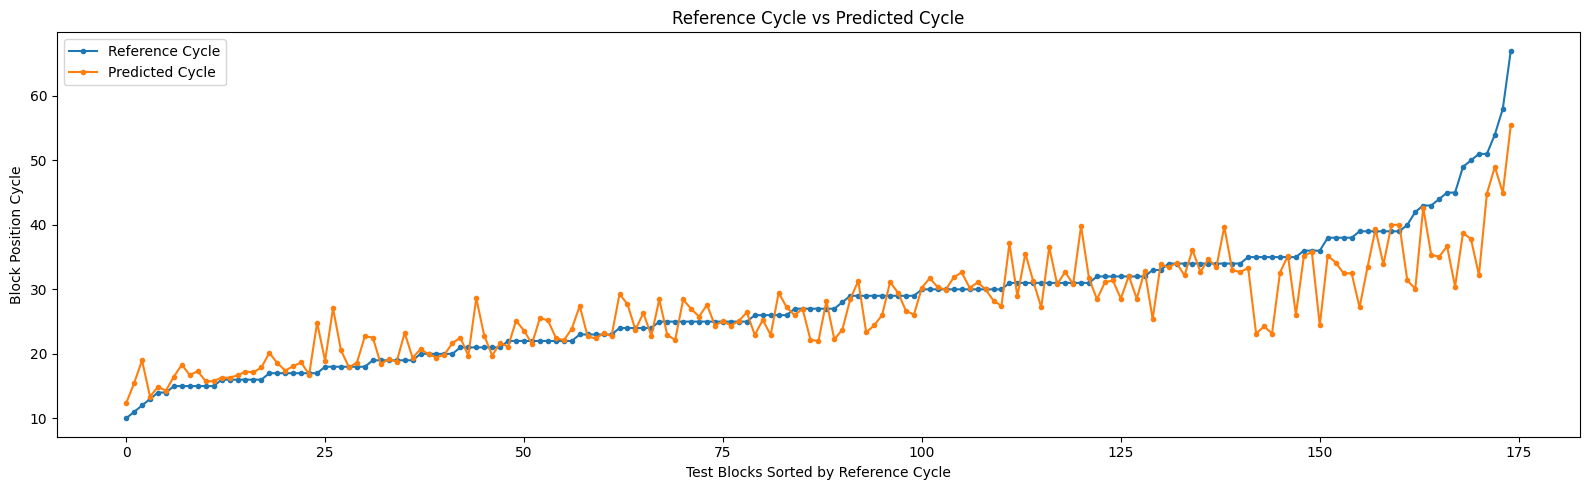

In [11]:
# ============================================================
# 기준 Cycle과 예측 Cycle 비교
# ============================================================

# 기준 Cycle이 짧은 Block부터 긴 Block 순으로 정렬
# x축은 block_index가 아니라 정렬된 Test Block의 순번
comparison_plot = residual_analysis.sort_values(
    'reference_cycle'
).reset_index(drop=True)

# 두 Cycle을 한눈에 비교하기 위해 가로로 긴 그래프 생성
plt.figure(figsize=(16, 5))

# Block Table에 주어진 기준 Cycle 표시
plt.plot(
    comparison_plot.index,
    comparison_plot['reference_cycle'],
    marker='o',
    markersize=3,
    label='Reference Cycle'
)

# 최종 Set A 모델의 예측 Cycle 표시
plt.plot(
    comparison_plot.index,
    comparison_plot['predicted_cycle'],
    marker='o',
    markersize=3,
    label='Predicted Cycle'
)

plt.xlabel('Test Blocks Sorted by Reference Cycle')
plt.ylabel('Block Position Cycle')
plt.title('Reference Cycle vs Predicted Cycle')
plt.legend()

plt.tight_layout()
plt.show()


### 3.7.3 변수 중요도

Tree 계열 모델은 변수 중요도, Linear/Ridge는 회귀계수의 절댓값을 사용한다. One-Hot Encoding 이후 생성된 범주도 각각의 변수로 표시한다.

> 중요도는 예측에 기여한 정도이며 인과관계를 의미하지 않는다.


In [12]:
# ============================================================
# 최종 모델 변수 중요도 확인
# ============================================================

# 전처리 이후 실제 모델에 입력된 변수명 추출
# → One-Hot Encoding된 범주형 변수까지 포함된 최종 Feature 이름
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

# ColumnTransformer가 붙인 'numeric__', 'categorical__' 접두사 제거
feature_names = [name.split('__', 1)[-1] for name in feature_names]


# Pipeline 내부에서 실제 학습된 회귀모델 불러오기
trained_estimator = final_model.named_steps['model']


# Tree 계열 모델은 feature_importances_ 사용
# 선형계열 모델은 회귀계수의 절댓값을 중요도로 사용
if hasattr(trained_estimator, 'feature_importances_'):
    importance_values = trained_estimator.feature_importances_
else:
    importance_values = np.abs(np.ravel(trained_estimator.coef_))


# 변수명과 중요도를 하나의 DataFrame으로 정리하고 중요도가 높은 순으로 정렬
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importance_values
}).sort_values('importance', ascending=False).reset_index(drop=True)


# 중요도가 높은 상위 15개 변수 확인
feature_importance.head(15).round(4)

,feature,importance
0,block_start_window,0.3170
1,block_width,0.2024
2,block_area,0.1703
3,block_weight,0.1574
4,block_length,0.0743
5,season_autumn,0.0198
6,season_spring,0.0168
7,season_winter,0.0160
8,season_summer,0.0110
9,block_ship_no_H1087,0.0046


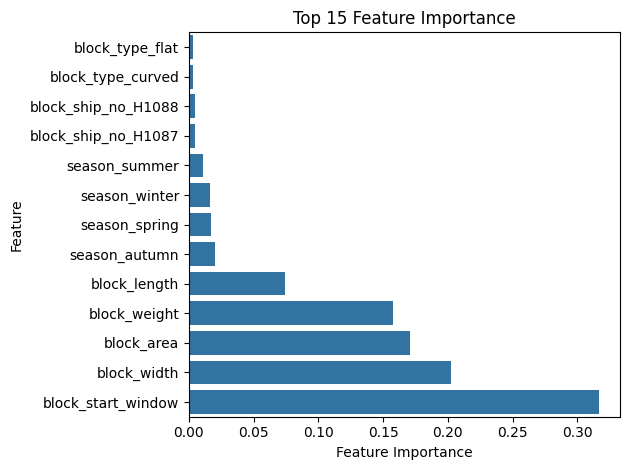

In [13]:
# ============================================================
# 중요도가 높은 상위 15개 변수 시각화
# ============================================================

# 상위 15개 변수를 선택하고, 막대그래프에서 큰 값이 위쪽에 오도록 정렬
top_importance = feature_importance.head(15).sort_values('importance')

# 변수별 중요도를 가로 막대그래프로 비교
sns.barplot(data=top_importance, x='importance', y='feature')

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importance')

plt.tight_layout()
plt.show()

#### 3.7.3.1 변수 중요도 소결론

최종 모델은 Block 고유 특성만 사용하므로 변수 중요도 역시 Cycle 사전 예측에 기여한 Block 변수로 제한된다. 중요도는 예측 기여도를 나타낼 뿐 인과관계를 의미하지 않는다.

이 결과는 향후 새로운 Block의 기준 처리기간을 추정하는 예측모델의 설명에 사용하며, Scheduling Method의 우열이나 선택 Position의 효과를 설명하는 데 사용하지 않는다.


## 3.8 결과 저장

Set A 기준모델 비교, 탐색적 Set A/B/C 비교, 최종 Set A 모델, 테스트 예측값과 변수 중요도를 저장한다. 4번 노트북은 이 모델을 스케줄링 점수 계산에 사용하지 않고 독립적으로 Result Table을 비교한다.


In [14]:
# ============================================================
# 모델링 결과 및 최종 Set A 모델 저장
# ============================================================

# 기준모델과 Feature Set 비교 결과 저장
baseline_results.to_csv(
    OUTPUT_DIR / '3_baseline_results.csv',
    index=False,
    encoding='utf-8-sig'
)

set_results.to_csv(
    OUTPUT_DIR / '3_feature_set_results.csv',
    index=False,
    encoding='utf-8-sig'
)


# Test 예측값과 변수 중요도 저장
residual_analysis.to_csv(
    OUTPUT_DIR / '3_test_predictions.csv',
    index=False,
    encoding='utf-8-sig'
)

feature_importance.to_csv(
    OUTPUT_DIR / '3_feature_importance.csv',
    index=False,
    encoding='utf-8-sig'
)


# 최종 Set A 모델 후보 비교표 저장
final_model_results.to_csv(
    OUTPUT_DIR / '3_final_model_results.csv',
    index=False,
    encoding='utf-8-sig'
)


# 튜닝된 최종 모델 저장
joblib.dump(
    final_model,
    OUTPUT_DIR / '3_final_model.joblib'
)


# 최종 결과 요약
modeling_summary = {
    'representative_model': representative_name,
    'final_variable_set': final_set_name,
    'final_model': final_candidate_name,
    'feature_role': 'pre-scheduling Block intrinsic features only',
    'best_params': grid_search.best_params_,
    'test_metrics': {
        'MAE': float(final_metrics.loc[0, 'MAE']),
        'RMSE': float(final_metrics.loc[0, 'RMSE']),
        'R2': float(final_metrics.loc[0, 'R2'])
    }
}


with open(
    OUTPUT_DIR / '3_modeling_summary.json',
    'w',
    encoding='utf-8'
) as file:
    json.dump(
        modeling_summary,
        file,
        ensure_ascii=False,
        indent=2
    )


print('모델링 결과 저장 완료')
print(
    json.dumps(
        modeling_summary,
        ensure_ascii=False,
        indent=2
    )
)


모델링 결과 저장 완료
{
  "representative_model": "Random Forest",
  "final_variable_set": "Set A - Block",
  "final_model": "Random Forest",
  "feature_role": "pre-scheduling Block intrinsic features only",
  "best_params": {
    "model__max_depth": null,
    "model__min_samples_leaf": 1,
    "model__n_estimators": 100
  },
  "test_metrics": {
    "MAE": 3.0021676190476194,
    "RMSE": 4.5578226968447355,
    "R2": 0.7670384757252314
  }
}


## 3.9 모델링 결론

- Set A에서 Random Forest가 가장 좋은 기준 성능을 보였다.
- 동일한 Random Forest의 탐색 비교는 **Set A > Set C > Set B** 순이었다.
- Position·Initial은 모든 스케줄링 기법의 실행 후 연결되는 결과층 정보이므로 최종 Cycle 예측변수에서 제외했다.
- 최종 모델은 **Set A + Random Forest**이며 Block 고유 특성으로 사전 Cycle을 예측한다.
- Set B/C 결과는 데이터 생성 순서를 재검토하게 만든 진단 실험으로 남긴다.

튜닝 전 Random Forest 후보의 Test RMSE는 4.489, R²는 0.774였다. GridSearchCV로 Train 데이터에서 파라미터를 선택한 최종 모델의 Test RMSE는 4.558, R²는 0.767이었다. 튜닝 후 Test 성능이 소폭 낮아졌으므로, 하이퍼파라미터 튜닝이 항상 별도 Test 데이터의 성능 향상을 보장하지 않는다는 점도 함께 기록한다.

다음 4번 노트북에서는 Cycle 예측 RMSE를 스케줄링 점수로 재사용하지 않는다. 7개 Result에 실제 기록된 Position 배정, Planned Start/Finish, Makespan과 Delay를 비교한다.
